
# MATH-500: FP16 vs INT8 Analysis

This notebook is dedicated only to the MATH-500 experiment.

It performs the following steps:

1. Loads the raw FP16 and INT8 result files.
2. Verifies that both runs contain the same 500 problems.
3. Computes accuracy for each configuration.
4. Performs paired per-problem analysis.
5. Computes a paired bootstrap confidence interval.
6. Performs an exact McNemar test.
7. Generates figures and summary tables.
8. Saves all analysis outputs to disk.




## 1. Imports and project paths

Update `FP16_PATH` and `INT8_PATH` if the result filenames are different.
        

In [5]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.home() / "kv_cache_project"

BASE_RESULTS_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "original_vllm"
)

RESULTS_DIR = BASE_RESULTS_DIR / "math500"
FIGURES_DIR = BASE_RESULTS_DIR / "figures" / "math500"
ANALYSIS_DIR = RESULTS_DIR / "analysis"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

FP16_PATH = (
    RESULTS_DIR
    / "math500_full_nothink_2048_auto.jsonl"
)

INT8_PATH = (
    RESULTS_DIR
    / "math500_full_nothink_2048_int8_per_token_head.jsonl"
)

COMPARISON_PATH = (
    RESULTS_DIR
    / "math500_full_2048_fp16_vs_int8.csv"
)

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)
print("FP16 results:", FP16_PATH)
print("INT8 results:", INT8_PATH)
print("Existing comparison:", COMPARISON_PATH)
print("Figures directory:", FIGURES_DIR)
print("Analysis directory:", ANALYSIS_DIR)

assert FP16_PATH.exists(), f"Missing FP16 file: {FP16_PATH}"
assert INT8_PATH.exists(), f"Missing INT8 file: {INT8_PATH}"

print("Result file validation passed.")

Project root: /home/shani.dayan/kv_cache_project
Results directory: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500
FP16 results: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/math500_full_nothink_2048_auto.jsonl
INT8 results: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/math500_full_nothink_2048_int8_per_token_head.jsonl
Existing comparison: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/math500_full_2048_fp16_vs_int8.csv
Figures directory: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/math500
Analysis directory: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/analysis
Result file validation passed.



## 2. Experiment configuration

This section records the exact experiment configuration.
        

In [6]:

EXPERIMENT_CONFIG = {
    "dataset": "MATH-500",
    "num_examples": 500,
    "max_new_tokens": 2048,
    "baseline_precision": "FP16",
    "quantized_precision": "INT8",
    "model_name": "TODO",
    "vllm_version_or_commit": "TODO",
    "gpu": "TODO",
    "seed": "TODO",
}

config_df = pd.DataFrame(
    EXPERIMENT_CONFIG.items(),
    columns=["parameter", "value"],
)

display(config_df)


,parameter,value
0,dataset,MATH-500
1,num_examples,500
2,max_new_tokens,2048
3,baseline_precision,FP16
4,quantized_precision,INT8
5,model_name,TODO
6,vllm_version_or_commit,TODO
7,gpu,TODO
8,seed,TODO



## 3. Load the raw result files

The loader supports JSONL, JSON, and CSV formats.
Each row should represent one MATH-500 problem.
        

In [7]:

def load_results(path: str | Path) -> pd.DataFrame:
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Results file was not found: {path}\n"
            "Update FP16_PATH / INT8_PATH or copy the files "
            "to the expected directory."
        )

    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".jsonl":
        rows = []

        with path.open("r", encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                line = line.strip()

                if not line:
                    continue

                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(
                        f"Invalid JSON on line {line_number} "
                        f"in {path}"
                    ) from exc

        return pd.DataFrame(rows)

    if suffix == ".json":
        with path.open("r", encoding="utf-8") as file:
            data = json.load(file)

        if isinstance(data, list):
            return pd.DataFrame(data)

        if isinstance(data, dict):
            for key in ("results", "examples", "data", "items"):
                if key in data and isinstance(data[key], list):
                    return pd.DataFrame(data[key])

        raise ValueError(
            f"Could not find a list of examples inside {path}"
        )

    raise ValueError(
        f"Unsupported file format: {suffix}. "
        "Use JSONL, JSON, or CSV."
    )


In [8]:

fp16_raw = load_results(FP16_PATH)
int8_raw = load_results(INT8_PATH)

print("FP16 shape:", fp16_raw.shape)
print("INT8 shape:", int8_raw.shape)

print("\nFP16 columns:")
print(fp16_raw.columns.tolist())

print("\nINT8 columns:")
print(int8_raw.columns.tolist())

display(fp16_raw.head(3))
display(int8_raw.head(3))


FP16 shape: (500, 25)
INT8 shape: (500, 25)

FP16 columns:
['dataset', 'dataset_index', 'unique_id', 'subject', 'level', 'problem', 'gold_solution', 'gold_answer', 'generated_text', 'final_response', 'correct', 'verification_error', 'prompt_tokens', 'output_tokens', 'finish_reason', 'reached_max_tokens', 'batch_elapsed_seconds', 'batch_size', 'model', 'kv_cache_dtype', 'thinking_enabled', 'temperature', 'seed', 'max_tokens', 'max_model_len']

INT8 columns:
['dataset', 'dataset_index', 'unique_id', 'subject', 'level', 'problem', 'gold_solution', 'gold_answer', 'generated_text', 'final_response', 'correct', 'verification_error', 'prompt_tokens', 'output_tokens', 'finish_reason', 'reached_max_tokens', 'batch_elapsed_seconds', 'batch_size', 'model', 'kv_cache_dtype', 'thinking_enabled', 'temperature', 'seed', 'max_tokens', 'max_model_len']


,dataset,dataset_index,unique_id,subject,level,problem,gold_solution,gold_answer,generated_text,final_response,correct,verification_error,prompt_tokens,output_tokens,finish_reason,reached_max_tokens,batch_elapsed_seconds,batch_size,model,kv_cache_dtype,thinking_enabled,temperature,seed,max_tokens,max_model_len
0,MATH-500,0,test/precalculus/807.json,Precalculus,2,"Convert the point $(0,3)$ in rectangular coord...",We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also...,"\left( 3, \frac{\pi}{2} \right)","To convert the point $(0, 3)$ from rectangular...","To convert the point $(0, 3)$ from rectangular...",True,None,98,175,stop,False,3.409024,5,/home/shani.dayan/.cache/huggingface/hub/model...,auto,False,0.0,2026,2048,4096
1,MATH-500,1,test/intermediate_algebra/1994.json,Intermediate Algebra,5,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...,We count the number of times $\frac{1}{n^3}$ a...,p - q,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,False,None,161,555,stop,False,3.409024,5,/home/shani.dayan/.cache/huggingface/hub/model...,auto,False,0.0,2026,2048,4096
2,MATH-500,2,test/algebra/2584.json,Algebra,3,"If $f(x) = \frac{3x-2}{x-2}$, what is the valu...",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3...,\frac{14}{3},We are given the function:\n\n$$\nf(x) = \frac...,We are given the function:\n\n$$\nf(x) = \frac...,True,None,98,327,stop,False,3.409024,5,/home/shani.dayan/.cache/huggingface/hub/model...,auto,False,0.0,2026,2048,4096


,dataset,dataset_index,unique_id,subject,level,problem,gold_solution,gold_answer,generated_text,final_response,correct,verification_error,prompt_tokens,output_tokens,finish_reason,reached_max_tokens,batch_elapsed_seconds,batch_size,model,kv_cache_dtype,thinking_enabled,temperature,seed,max_tokens,max_model_len
0,MATH-500,0,test/precalculus/807.json,Precalculus,2,"Convert the point $(0,3)$ in rectangular coord...",We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also...,"\left( 3, \frac{\pi}{2} \right)","$$\n\boxed{(3, \frac{\pi}{3})}\n$$","$$\n\boxed{(3, \frac{\pi}{3})}\n$$",False,None,98,17,stop,False,2.941918,5,/home/shani.dayan/.cache/huggingface/hub/model...,int8_per_token_head,False,0.0,2026,2048,4096
1,MATH-500,1,test/intermediate_algebra/1994.json,Intermediate Algebra,5,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...,We count the number of times $\frac{1}{n^3}$ a...,p - q,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,True,None,161,530,stop,False,2.941918,5,/home/shani.dayan/.cache/huggingface/hub/model...,int8_per_token_head,False,0.0,2026,2048,4096
2,MATH-500,2,test/algebra/2584.json,Algebra,3,"If $f(x) = \frac{3x-2}{x-2}$, what is the valu...",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3...,\frac{14}{3},We are given the function:\n\n$$\nf(x) = \frac...,We are given the function:\n\n$$\nf(x) = \frac...,True,None,98,330,stop,False,2.941918,5,/home/shani.dayan/.cache/huggingface/hub/model...,int8_per_token_head,False,0.0,2026,2048,4096



## 4. Normalize column names

Different evaluation scripts may use different column names.
The following code attempts to identify the problem ID, correctness
value, generated answer, reference answer, latency, token count,
and peak memory automatically.
        

In [9]:

COLUMN_CANDIDATES = {
    "problem_id": [
        "problem_id",
        "id",
        "sample_id",
        "example_id",
        "index",
        "idx",
    ],
    "correct": [
        "correct",
        "is_correct",
        "exact_match",
        "em",
        "accuracy",
    ],
    "generated_answer": [
        "generated_answer",
        "prediction",
        "predicted_answer",
        "output",
        "response",
        "generated_text",
    ],
    "reference_answer": [
        "reference_answer",
        "answer",
        "ground_truth",
        "target",
        "expected_answer",
        "solution",
    ],
    "latency_s": [
        "latency_s",
        "latency",
        "elapsed_seconds",
        "generation_time_s",
        "runtime_s",
    ],
    "generated_tokens": [
        "generated_tokens",
        "num_generated_tokens",
        "output_tokens",
        "completion_tokens",
    ],
    "peak_memory_mb": [
        "peak_memory_mb",
        "gpu_peak_memory_mb",
        "max_memory_mb",
        "memory_mb",
    ],
}


def find_column(
    df: pd.DataFrame,
    logical_name: str,
    required: bool = False,
):
    for candidate in COLUMN_CANDIDATES[logical_name]:
        if candidate in df.columns:
            return candidate

    if required:
        raise KeyError(
            f"Could not identify '{logical_name}'. "
            f"Available columns: {df.columns.tolist()}"
        )

    return None


def normalize_results(
    df: pd.DataFrame,
    precision: str,
) -> pd.DataFrame:
    id_col = find_column(
        df,
        "problem_id",
        required=False,
    )

    correct_col = find_column(
        df,
        "correct",
        required=True,
    )

    normalized = pd.DataFrame()

    if id_col is None:
        normalized["problem_id"] = np.arange(len(df))
    else:
        normalized["problem_id"] = df[id_col]

    normalized["correct"] = (
        pd.to_numeric(
            df[correct_col],
            errors="coerce",
        )
        .fillna(0)
        .astype(int)
    )

    optional_columns = (
        "generated_answer",
        "reference_answer",
        "latency_s",
        "generated_tokens",
        "peak_memory_mb",
    )

    for logical_name in optional_columns:
        source_col = find_column(
            df,
            logical_name,
            required=False,
        )

        if source_col is not None:
            normalized[logical_name] = df[source_col]

    normalized["precision"] = precision

    return normalized


fp16 = normalize_results(fp16_raw, "FP16")
int8 = normalize_results(int8_raw, "INT8")

display(fp16.head())
display(int8.head())


,problem_id,correct,generated_answer,generated_tokens,precision
0,0,1,"To convert the point $(0, 3)$ from rectangular...",175,FP16
1,1,0,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,555,FP16
2,2,1,We are given the function:\n\n$$\nf(x) = \frac...,327,FP16
3,3,1,To find the number of positive whole-number di...,118,FP16
4,4,1,To determine which student has the greatest av...,305,FP16


,problem_id,correct,generated_answer,generated_tokens,precision
0,0,0,"$$\n\boxed{(3, \frac{\pi}{3})}\n$$",17,INT8
1,1,1,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,530,INT8
2,2,1,We are given the function:\n\n$$\nf(x) = \frac...,330,INT8
3,3,1,To find the number of positive whole-number di...,199,INT8
4,4,0,\boxed{final answer},7,INT8



## 5. Validate the two runs

The validation checks that:

1. Each run contains exactly 500 problems.
2. There are no duplicate problem IDs.
3. Correctness values are either 0 or 1.
4. FP16 and INT8 contain the same problem IDs.
        

In [10]:

EXPECTED_EXAMPLES = 500


def validate_single_run(
    df: pd.DataFrame,
    name: str,
):
    assert len(df) == EXPECTED_EXAMPLES, (
        f"{name}: expected {EXPECTED_EXAMPLES} rows, "
        f"found {len(df)}"
    )

    assert not df["problem_id"].duplicated().any(), (
        f"{name}: duplicate problem IDs were found"
    )

    invalid_values = (
        set(df["correct"].dropna().unique()) - {0, 1}
    )

    assert not invalid_values, (
        f"{name}: invalid values in 'correct': "
        f"{invalid_values}"
    )


validate_single_run(fp16, "FP16")
validate_single_run(int8, "INT8")

fp16_ids = set(fp16["problem_id"])
int8_ids = set(int8["problem_id"])

assert fp16_ids == int8_ids, (
    "FP16 and INT8 do not contain exactly the same "
    "problem IDs.\n"
    f"Only in FP16: "
    f"{sorted(fp16_ids - int8_ids)[:10]}\n"
    f"Only in INT8: "
    f"{sorted(int8_ids - fp16_ids)[:10]}"
)

print("Validation passed.")
print(
    "Both runs contain the same 500 MATH-500 problems."
)


Validation passed.
Both runs contain the same 500 MATH-500 problems.



        ## 6. Merge the paired results

        The two runs are merged by problem ID so that FP16 and INT8
        can be compared on the same problem.
        

In [11]:

fp16_renamed = fp16.rename(
    columns={
        column: f"fp16_{column}"
        for column in fp16.columns
        if column not in ("problem_id", "precision")
    }
).drop(columns=["precision"])

int8_renamed = int8.rename(
    columns={
        column: f"int8_{column}"
        for column in int8.columns
        if column not in ("problem_id", "precision")
    }
).drop(columns=["precision"])

paired = fp16_renamed.merge(
    int8_renamed,
    on="problem_id",
    how="inner",
    validate="one_to_one",
)

paired = (
    paired
    .sort_values("problem_id")
    .reset_index(drop=True)
)

print("Paired shape:", paired.shape)
display(paired.head())


Paired shape: (500, 7)


,problem_id,fp16_correct,fp16_generated_answer,fp16_generated_tokens,int8_correct,int8_generated_answer,int8_generated_tokens
0,0,1,"To convert the point $(0, 3)$ from rectangular...",175,0,"$$\n\boxed{(3, \frac{\pi}{3})}\n$$",17
1,1,0,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,555,1,We are given:\n\n$$\np = \sum_{k = 1}^\infty \...,530
2,2,1,We are given the function:\n\n$$\nf(x) = \frac...,327,1,We are given the function:\n\n$$\nf(x) = \frac...,330
3,3,1,To find the number of positive whole-number di...,118,1,To find the number of positive whole-number di...,199
4,4,1,To determine which student has the greatest av...,305,0,\boxed{final answer},7



        ## 7. Accuracy comparison

        Accuracy is the percentage of the 500 problems that were
        answered correctly.
        

In [12]:

fp16_accuracy = paired["fp16_correct"].mean()
int8_accuracy = paired["int8_correct"].mean()

accuracy_difference = (
    int8_accuracy - fp16_accuracy
)

accuracy_summary = pd.DataFrame(
    {
        "configuration": ["FP16", "INT8"],
        "correct": [
            int(paired["fp16_correct"].sum()),
            int(paired["int8_correct"].sum()),
        ],
        "total": [
            len(paired),
            len(paired),
        ],
        "accuracy": [
            fp16_accuracy,
            int8_accuracy,
        ],
        "accuracy_percent": [
            100 * fp16_accuracy,
            100 * int8_accuracy,
        ],
    }
)

display(accuracy_summary)

print(
    f"FP16 accuracy: "
    f"{100 * fp16_accuracy:.2f}%"
)

print(
    f"INT8 accuracy: "
    f"{100 * int8_accuracy:.2f}%"
)

print(
    "INT8 - FP16 difference: "
    f"{100 * accuracy_difference:.2f} "
    "percentage points"
)


,configuration,correct,total,accuracy,accuracy_percent
0,FP16,224,500,0.448,44.8
1,INT8,218,500,0.436,43.6


FP16 accuracy: 44.80%
INT8 accuracy: 43.60%
INT8 - FP16 difference: -1.20 percentage points


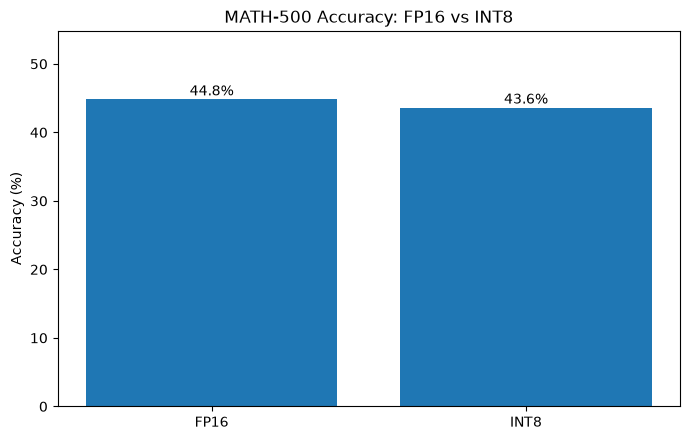

Saved: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/math500/math500_accuracy_fp16_vs_int8.png


In [13]:

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(
    accuracy_summary["configuration"],
    accuracy_summary["accuracy_percent"],
)

ax.set_ylabel("Accuracy (%)")
ax.set_title(
    "MATH-500 Accuracy: FP16 vs INT8"
)

ax.set_ylim(
    0,
    max(
        accuracy_summary["accuracy_percent"]
    ) + 10,
)

for index, value in enumerate(
    accuracy_summary["accuracy_percent"]
):
    ax.text(
        index,
        value + 0.6,
        f"{value:.1f}%",
        ha="center",
    )

fig.tight_layout()

accuracy_figure_path = (
    FIGURES_DIR
    / "math500_accuracy_fp16_vs_int8.png"
)

fig.savefig(
    accuracy_figure_path,
    dpi=200,
)

plt.show()

print("Saved:", accuracy_figure_path)



## 8. Paired outcomes

Each problem belongs to one of four categories:

- Correct in both configurations.
- Correct only in FP16.
- Correct only in INT8.
- Wrong in both configurations.
        

In [14]:

both_correct = int(
    (
        (paired["fp16_correct"] == 1)
        & (paired["int8_correct"] == 1)
    ).sum()
)

fp16_only = int(
    (
        (paired["fp16_correct"] == 1)
        & (paired["int8_correct"] == 0)
    ).sum()
)

int8_only = int(
    (
        (paired["fp16_correct"] == 0)
        & (paired["int8_correct"] == 1)
    ).sum()
)

both_wrong = int(
    (
        (paired["fp16_correct"] == 0)
        & (paired["int8_correct"] == 0)
    ).sum()
)

paired_outcomes = pd.DataFrame(
    {
        "outcome": [
            "Correct in both",
            "Correct only in FP16",
            "Correct only in INT8",
            "Wrong in both",
        ],
        "count": [
            both_correct,
            fp16_only,
            int8_only,
            both_wrong,
        ],
    }
)

assert paired_outcomes["count"].sum() == len(paired)

display(paired_outcomes)


,outcome,count
0,Correct in both,167
1,Correct only in FP16,57
2,Correct only in INT8,51
3,Wrong in both,225


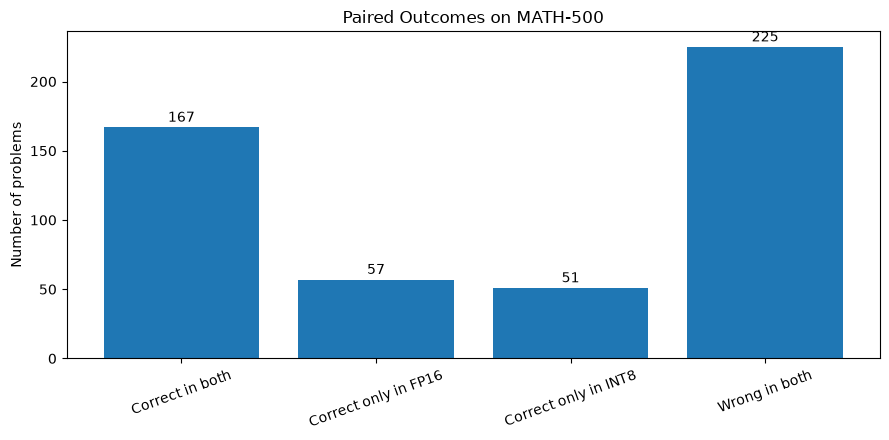

Saved: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/math500/math500_paired_outcomes.png


In [15]:

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(
    paired_outcomes["outcome"],
    paired_outcomes["count"],
)

ax.set_ylabel("Number of problems")
ax.set_title("Paired Outcomes on MATH-500")
ax.tick_params(axis="x", rotation=20)

for index, value in enumerate(
    paired_outcomes["count"]
):
    ax.text(
        index,
        value + 4,
        str(value),
        ha="center",
    )

fig.tight_layout()

paired_figure_path = (
    FIGURES_DIR
    / "math500_paired_outcomes.png"
)

fig.savefig(
    paired_figure_path,
    dpi=200,
)

plt.show()

print("Saved:", paired_figure_path)



## 9. Paired bootstrap confidence interval

The accuracy difference is defined as:

`INT8 accuracy - FP16 accuracy`

A negative result indicates that FP16 achieved higher accuracy.

Paired bootstrap sampling preserves the correspondence between
the FP16 and INT8 result for each problem.
        

In [16]:

def paired_bootstrap_accuracy_difference(
    fp16_correct,
    int8_correct,
    n_bootstrap: int = 10_000,
    seed: int = 42,
):
    fp16_correct = np.asarray(
        fp16_correct,
        dtype=float,
    )

    int8_correct = np.asarray(
        int8_correct,
        dtype=float,
    )

    if fp16_correct.shape != int8_correct.shape:
        raise ValueError(
            "The paired arrays must have "
            "identical shapes."
        )

    rng = np.random.default_rng(seed)
    n_examples = len(fp16_correct)

    bootstrap_differences = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for sample_index in range(n_bootstrap):
        sampled_indices = rng.integers(
            0,
            n_examples,
            size=n_examples,
        )

        bootstrap_differences[sample_index] = (
            int8_correct[
                sampled_indices
            ].mean()
            - fp16_correct[
                sampled_indices
            ].mean()
        )

    point_estimate = (
        int8_correct.mean()
        - fp16_correct.mean()
    )

    ci_low, ci_high = np.percentile(
        bootstrap_differences,
        [2.5, 97.5],
    )

    return {
        "point_estimate": point_estimate,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "samples": bootstrap_differences,
    }


bootstrap = (
    paired_bootstrap_accuracy_difference(
        paired["fp16_correct"],
        paired["int8_correct"],
        n_bootstrap=10_000,
        seed=42,
    )
)

print(
    "Accuracy difference (INT8 - FP16): "
    f"{100 * bootstrap['point_estimate']:.2f} pp"
)

print(
    "95% paired bootstrap CI: "
    f"[{100 * bootstrap['ci_low']:.2f}, "
    f"{100 * bootstrap['ci_high']:.2f}] pp"
)


Accuracy difference (INT8 - FP16): -1.20 pp
95% paired bootstrap CI: [-5.40, 2.80] pp


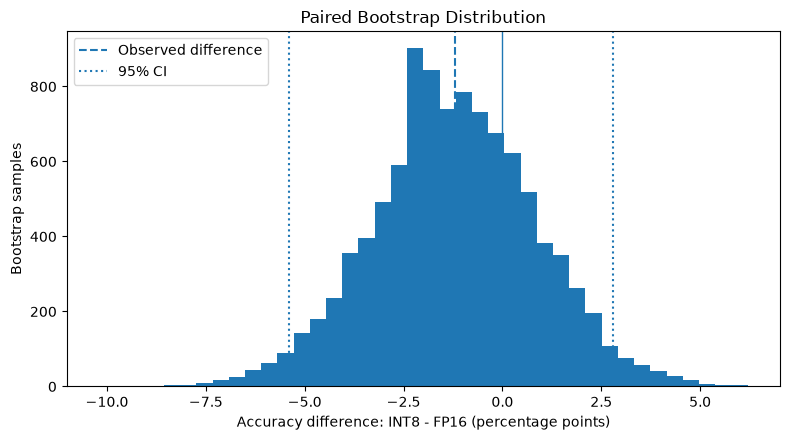

Saved: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/math500/math500_bootstrap_difference.png


In [17]:

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(
    100 * bootstrap["samples"],
    bins=40,
)

ax.axvline(
    100 * bootstrap["point_estimate"],
    linestyle="--",
    label="Observed difference",
)

ax.axvline(
    100 * bootstrap["ci_low"],
    linestyle=":",
    label="95% CI",
)

ax.axvline(
    100 * bootstrap["ci_high"],
    linestyle=":",
)

ax.axvline(0, linewidth=1)

ax.set_xlabel(
    "Accuracy difference: INT8 - FP16 "
    "(percentage points)"
)

ax.set_ylabel("Bootstrap samples")
ax.set_title(
    "Paired Bootstrap Distribution"
)

ax.legend()
fig.tight_layout()

bootstrap_figure_path = (
    FIGURES_DIR
    / "math500_bootstrap_difference.png"
)

fig.savefig(
    bootstrap_figure_path,
    dpi=200,
)

plt.show()

print("Saved:", bootstrap_figure_path)



## 10. Exact McNemar test

The McNemar test compares the number of problems that were
correct only in FP16 with the number that were correct only
in INT8.

This implementation computes the exact two-sided binomial
test and does not require SciPy.
        

In [18]:

def exact_mcnemar_pvalue(
    fp16_only_count: int,
    int8_only_count: int,
) -> float:
    discordant = (
        fp16_only_count
        + int8_only_count
    )

    if discordant == 0:
        return 1.0

    smaller_count = min(
        fp16_only_count,
        int8_only_count,
    )

    one_sided_probability = sum(
        math.comb(discordant, k)
        for k in range(
            smaller_count + 1
        )
    ) / (2 ** discordant)

    return min(
        1.0,
        2 * one_sided_probability,
    )


mcnemar_pvalue = exact_mcnemar_pvalue(
    fp16_only,
    int8_only,
)

print(
    "Correct only in FP16:",
    fp16_only,
)

print(
    "Correct only in INT8:",
    int8_only,
)

print(
    f"Exact McNemar p-value: "
    f"{mcnemar_pvalue:.6f}"
)


Correct only in FP16: 57
Correct only in INT8: 51
Exact McNemar p-value: 0.630634



## 11. Optional latency, token, and memory metrics

This section runs only when both result files contain the
relevant metric.
        

In [19]:

OPTIONAL_METRICS = {
    "latency_s": "Latency (seconds)",
    "generated_tokens": "Generated tokens",
    "peak_memory_mb": "Peak GPU memory (MB)",
}


def summarize_optional_metric(
    paired_df: pd.DataFrame,
    metric_name: str,
):
    fp16_column = f"fp16_{metric_name}"
    int8_column = f"int8_{metric_name}"

    if (
        fp16_column not in paired_df.columns
        or int8_column not in paired_df.columns
    ):
        print(
            f"Skipping '{metric_name}': "
            "the metric is not available "
            "for both runs."
        )
        return None

    fp16_values = pd.to_numeric(
        paired_df[fp16_column],
        errors="coerce",
    )

    int8_values = pd.to_numeric(
        paired_df[int8_column],
        errors="coerce",
    )

    summary = pd.DataFrame(
        {
            "configuration": [
                "FP16",
                "INT8",
            ],
            "mean": [
                fp16_values.mean(),
                int8_values.mean(),
            ],
            "median": [
                fp16_values.median(),
                int8_values.median(),
            ],
            "std": [
                fp16_values.std(),
                int8_values.std(),
            ],
            "min": [
                fp16_values.min(),
                int8_values.min(),
            ],
            "max": [
                fp16_values.max(),
                int8_values.max(),
            ],
        }
    )

    print(f"\nMetric: {metric_name}")
    display(summary)

    return summary


optional_summaries = {}

for metric_name in OPTIONAL_METRICS:
    optional_summaries[metric_name] = (
        summarize_optional_metric(
            paired,
            metric_name,
        )
    )


Skipping 'latency_s': the metric is not available for both runs.

Metric: generated_tokens


,configuration,mean,median,std,min,max
0,FP16,456.926,306.0,446.290716,16,2048
1,INT8,416.954,267.0,414.362687,6,2048


Skipping 'peak_memory_mb': the metric is not available for both runs.



## 12. Save the analysis outputs

The following files are saved:

- Accuracy summary.
- Paired-outcome summary.
- Full paired results.
- Statistical summary in JSON format.
        

In [20]:

accuracy_summary_path = (
    ANALYSIS_DIR
    / "accuracy_summary.csv"
)

paired_outcomes_path = (
    ANALYSIS_DIR
    / "paired_outcomes.csv"
)

paired_results_path = (
    ANALYSIS_DIR
    / "paired_results.csv"
)

statistics_path = (
    ANALYSIS_DIR
    / "statistics_summary.json"
)

accuracy_summary.to_csv(
    accuracy_summary_path,
    index=False,
)

paired_outcomes.to_csv(
    paired_outcomes_path,
    index=False,
)

paired.to_csv(
    paired_results_path,
    index=False,
)

statistics_summary = {
    "num_examples": len(paired),
    "fp16_accuracy": float(
        fp16_accuracy
    ),
    "int8_accuracy": float(
        int8_accuracy
    ),
    "accuracy_difference_int8_minus_fp16": (
        float(accuracy_difference)
    ),
    "bootstrap_ci_95": {
        "low": float(
            bootstrap["ci_low"]
        ),
        "high": float(
            bootstrap["ci_high"]
        ),
    },
    "paired_outcomes": {
        "both_correct": both_correct,
        "fp16_only": fp16_only,
        "int8_only": int8_only,
        "both_wrong": both_wrong,
    },
    "exact_mcnemar_pvalue": float(
        mcnemar_pvalue
    ),
}

with statistics_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        statistics_summary,
        file,
        indent=2,
    )

print("Saved analysis files:")
print("-", accuracy_summary_path)
print("-", paired_outcomes_path)
print("-", paired_results_path)
print("-", statistics_path)


Saved analysis files:
- /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/analysis/accuracy_summary.csv
- /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/analysis/paired_outcomes.csv
- /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/analysis/paired_results.csv
- /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/math500/analysis/statistics_summary.json



## 13. Sanity check against the recorded result

The recorded MATH-500 experiment produced:

- 224 correct FP16 answers.
- 218 correct INT8 answers.
- 167 problems correct in both.
- 57 problems correct only in FP16.
- 51 problems correct only in INT8.
- 225 problems wrong in both.
        

In [21]:

EXPECTED_RESULTS = {
    "fp16_correct": 224,
    "int8_correct": 218,
    "both_correct": 167,
    "fp16_only": 57,
    "int8_only": 51,
    "both_wrong": 225,
}

actual_results = {
    "fp16_correct": int(
        paired["fp16_correct"].sum()
    ),
    "int8_correct": int(
        paired["int8_correct"].sum()
    ),
    "both_correct": both_correct,
    "fp16_only": fp16_only,
    "int8_only": int8_only,
    "both_wrong": both_wrong,
}

for key, expected_value in (
    EXPECTED_RESULTS.items()
):
    actual_value = actual_results[key]

    assert actual_value == expected_value, (
        f"{key}: expected {expected_value}, "
        f"found {actual_value}"
    )

print("Sanity check passed.")
print(
    "The loaded files reproduce the "
    "recorded MATH-500 result."
)


Sanity check passed.
The loaded files reproduce the recorded MATH-500 result.



## 14. Conclusion

For MATH-500 with 2048 generated tokens:

- FP16 accuracy: **44.8%**
- INT8 accuracy: **43.6%**
- Accuracy difference: **-1.2 percentage points**
- 95% paired bootstrap confidence interval: **[-5.2, 2.8]**
- Exact McNemar p-value: **0.630634**

The confidence interval includes zero and the McNemar test
is not statistically significant. Therefore, this experiment
does not provide evidence that INT8 significantly reduces
answer quality relative to FP16.

This result does not prove that the two configurations are
equivalent. Future experiments should also compare GPU memory
usage, KV cache size, latency, throughput, and longer context
lengths.
